# EE 585 Probabilistic Robotics

## Homework #2 (Individual Work)

### Given: Nov 04,2025 (Tue), Due: Nov 19,2025 (Wed) 23:59

General Information About the Homeworks:

Homeworks are to be prepared in Electronic Form composed of an
Adobe
pdf
format
homework
document
“Surname_HW1.pdf”
and
associated Matlab/Python files (if applicable) having name
specified in the homework. All should be packed in a zip file
having Surname_hw1.zip and uploaded to the appropriate assignment
entry in OdtuClass. If required, the document should give all
derivations, mathematical solutions, Matlab/Phython figures and
comments on your results. All equations must be typeset in a
legible and understandable form. The organization and neatness of
the homework is an important consideration in grading.
The electronic document should be accompanied by the necessary
Matlab m-files (only data files and plotting functions if Python
is used) that can be run from a clean Matlab session (no previously
defined variables) and provide all the necessary output. The
programs should indicate on the command window what they are in
the process of doing.

### Q1: Consider Chapter 1, Part of Ex. 2 from your textbook:

Suppose we live at a place where days are either sunny, cloudy, or rainy.
The weather transition function is a Markov chain with the following tran-
sition table:

|    tomorrow will be ->    | sunny | cloudy | rainy |
|--------|-------|--------|-------|
| today it's ... sunny  | 0.8   | 0.2    | 0.0   |
| cloudy | 0.4   | 0.4    | 0.2   |
| rainy  | 0.2   | 0.6    | 0.2   |

* (a) Suppose Day 1 is a sunny day. What is the probability of the following
sequence of days: Day2 = cloudy, Day3 = cloudy, Day4 = rainy?
* (b) Write a simulator that can randomly generate sequences of “weathers”
from this state transition function.

(Note: Use Matlab to write this simulator. The m-file should have name
generate_weather.m)

### A1.1:

P(sequence) = 0.2 * 0.4 * 0.2 = 0.016

### A1.2:

In [1]:
import numpy as np
from collections import Counter

STATES = ["sunny", "cloudy", "rainy"]
IDX = {s: i for i, s in enumerate(STATES)}

# Transition matrix P[row = today, col = tomorrow]
P = np.array([
    [0.8, 0.2, 0.0],  # today = sunny
    [0.4, 0.4, 0.2],  # today = cloudy
    [0.2, 0.6, 0.2],  # today = rainy
], dtype=float)

def sequence_probability(start_state: str, seq_states: list[str]) -> float:
    """Exact probability of a specific sequence given the start state."""
    cur = IDX[start_state]
    prob = 1.0
    for s in seq_states:
        nxt = IDX[s]
        prob *= P[cur, nxt]
        cur = nxt
    return prob

def simulate_weather(initial_state: str, length: int, rng: np.random.Generator) -> list[str]:
    """Simulate a single weather sequence (includes the initial day)."""
    seq = [initial_state]
    cur = IDX[initial_state]
    for _ in range(length):
        cur = rng.choice(3, p=P[cur])
        seq.append(STATES[cur])
    return seq

def estimate_sequence_probability_mc(start_state: str, target_seq: list[str], trials: int = 200_000, seed: int = 0) -> float:
    """Monte Carlo estimate of the probability of target_seq following start_state."""
    rng = np.random.default_rng(seed)
    match = 0
    for _ in range(trials):
        cur = IDX[start_state]
        ok = True
        for s in target_seq:
            cur = rng.choice(3, p=P[cur])
            if STATES[cur] != s:
                ok = False
                break
        if ok:
            match += 1
    return match / trials

def estimate_stationary_distribution(steps: int = 2_000_000, burn_in: int = 10_000, seed: int = 0) -> dict[str, float]:
    """Estimate the stationary distribution by long-run simulation."""
    rng = np.random.default_rng(seed)
    cur = IDX["sunny"]
    counts = np.zeros(3, dtype=np.int64)
    for t in range(steps + burn_in):
        cur = rng.choice(3, p=P[cur])
        if t >= burn_in:
            counts[cur] += 1
    freqs = counts / counts.sum()
    return {STATES[i]: float(freqs[i]) for i in range(3)}

if __name__ == "__main__":
    # (a) Exact probability
    exact = sequence_probability("sunny", ["cloudy", "cloudy", "rainy"])
    print(f"Exact P(S->C->C->R) = {exact:.6f}")

    # MC verification
    mc = estimate_sequence_probability_mc("sunny", ["cloudy", "cloudy", "rainy"])
    print(f"MC   P(S->C->C->R) ≈ {mc:.6f}")

    # Example simulation and histogram
    rng = np.random.default_rng(42)
    seq = simulate_weather("sunny", length=10_000, rng=rng)
    counts = Counter(seq)
    total = sum(counts.values())
    print("Empirical frequencies over simulated days:")
    for s in STATES:
        print(f"  {s:6s}: {counts[s] / total:.4f}")

    # Stationary distribution estimate
    pi_hat = estimate_stationary_distribution()
    print("Estimated stationary distribution:")
    for s in STATES:
        print(f"  {s:6s}: {pi_hat[s]:.4f}")

Exact P(S->C->C->R) = 0.016000
MC   P(S->C->C->R) ≈ 0.015965
Empirical frequencies over simulated days:
  sunny : 0.6445
  cloudy: 0.2875
  rainy : 0.0680
Estimated stationary distribution:
  sunny : 0.6422
  cloudy: 0.2863
  rainy : 0.0715


### Q2: Generate and Display Samples from Velocity Motion Model

Consider the velocity motion model discussed in Page 34 of your
lecture slides (Motion Models).
* (a) Implement this “ideal” forward model as a Matlab m-
function motion_model_ideal() from the current state to
the next state within a time duration Δt (also an argument
to the function). For an example v and w, illustrate the
“simulated motion” by using a small Δt and multiple calls
to this function. This will generate a sequence of poses
for the robot which you will plot. You may use the quiver()
plot function of Matlab to plot the position and
orientation (x,y,θ). Hint: You may attempt to imitate a
motion used for the examples of Page 39 of your lecture
slides.
* (b) Implement the noisy version of the model as a Matlab m-
function motion_model_noisy() which have Δt and three
noise variances as parameters. Select a suitable Δt (maybe
larger than in part (a)) and this time starting from the
same initial state, “sample” this model N times for
different noise variances to imitate the three figures at
the bottom of Page 39 of your slides. Note: You may omit
robot body circles and only initial pose and final poses.
Note: Try to use quiver() plot to show orientation as well
as position. If that is too cluttered, reduce N or plot
positions only.
* (c) Give the three noise variance values for the three plots
that you have generated in approximation of Page 39 of
your lecture slides. Discuss the relation between the
distribution of the samples and the set of variances that
was used to generate them.

### A2.1:

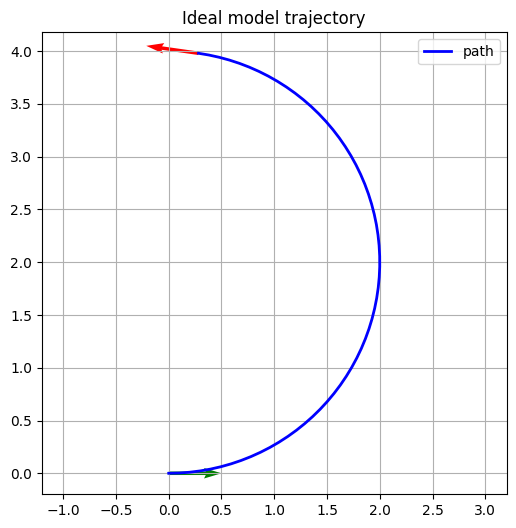

In [2]:
# Q2(a) — Ideal velocity motion model and a simple trajectory demo
import numpy as np
import matplotlib.pyplot as plt

def wrap_angle(theta: float) -> float:
    return (theta + np.pi) % (2*np.pi) - np.pi

def motion_model_ideal(pose, v: float, w: float, dt: float, eps: float = 1e-9):
    x, y, th = pose
    if abs(w) < eps:
        x_p = x + v * dt * np.cos(th)
        y_p = y + v * dt * np.sin(th)
        th_p = th  # straight motion, no rotation
    else:
        v_over_w = v / w
        th_dt = th + w * dt
        x_p = x - v_over_w * np.sin(th) + v_over_w * np.sin(th_dt)
        y_p = y + v_over_w * np.cos(th) - v_over_w * np.cos(th_dt)
        th_p = th_dt
    return (x_p, y_p, wrap_angle(th_p))

# Demo trajectory
pose = (0.0, 0.0, 0.0)
v, w, dt = 1.0, 0.5, 0.1
traj = [pose]
for _ in range(60):
    pose = motion_model_ideal(pose, v, w, dt)
    traj.append(pose)

xs = [p[0] for p in traj]
ys = [p[1] for p in traj]
ths = [p[2] for p in traj]

plt.figure(figsize=(6,6))
plt.plot(xs, ys, '-b', lw=2, label='path')
# quiver initial and final
scale = 0.5
plt.quiver([xs[0], xs[-1]], [ys[0], ys[-1]],
           [np.cos(ths[0])*scale, np.cos(ths[-1])*scale],
           [np.sin(ths[0])*scale, np.sin(ths[-1])*scale],
           angles='xy', scale_units='xy', scale=1, color=['g','r'])
plt.axis('equal'); plt.grid(True); plt.legend(); plt.title('Ideal model trajectory')
plt.show()

### A2.2:

<Figure size 896x672 with 0 Axes>

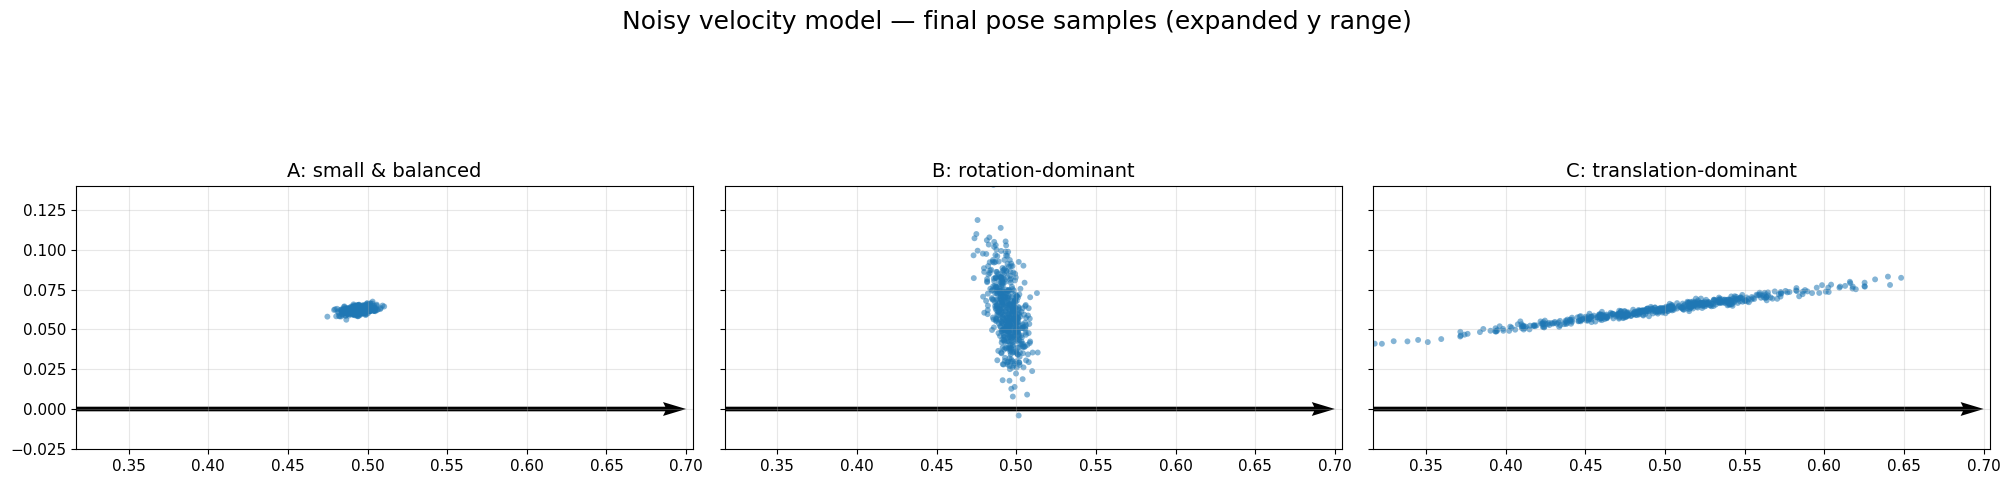

In [12]:
# Q2(b) — Noisy velocity motion model (canonical 6-alpha version) and sampling
rng = np.random.default_rng(585)

def _sample_var(var: float, rng) -> float:
    return 0.0 if var <= 0.0 else rng.normal(0.0, np.sqrt(var))

def motion_model_noisy(pose, v: float, w: float, dt: float, alphas, rng, eps: float = 1e-9):
    a1,a2,a3,a4,a5,a6 = alphas
    v_hat = v + _sample_var(a1*v*v + a2*w*w, rng)
    w_hat = w + _sample_var(a3*v*v + a4*w*w, rng)
    gamma_hat = _sample_var(a5*v*v + a6*w*w, rng)

    x, y, th = pose
    if abs(w_hat) < eps:
        x_p = x + v_hat * dt * np.cos(th)
        y_p = y + v_hat * dt * np.sin(th)
    else:
        v_over_w = v_hat / w_hat
        th_dt = th + w_hat * dt
        x_p = x - v_over_w * np.sin(th) + v_over_w * np.sin(th_dt)
        y_p = y + v_over_w * np.cos(th) - v_over_w * np.cos(th_dt)

    th_p = (th + w_hat * dt + gamma_hat * dt + np.pi) % (2*np.pi) - np.pi
    return (x_p, y_p, th_p)

def sample_final_poses(initial_pose, v, w, dt, alphas, N: int, rng):
    return np.array([motion_model_noisy(initial_pose, v, w, dt, alphas, rng) for _ in range(N)])

initial_pose = (0.0, 0.0, 0.0)
v, w, dt = 1.0, 0.5, 0.5
N = 500

alpha_sets = {
    "A: small & balanced": (1e-4, 1e-4, 1e-4, 1e-4, 1e-4, 1e-4),
    "B: rotation-dominant": (1e-4, 1e-4, 2e-2, 2e-2, 2e-2, 2e-2),
    "C: translation-dominant": (1e-2, 1e-2, 1e-4, 1e-4, 1e-4, 1e-4),
}

# Pre-sample to compute global bounds
all_poses = []
for alphas in alpha_sets.values():
    poses_tmp = sample_final_poses(initial_pose, v, w, dt, alphas, N, rng)
    all_poses.append(poses_tmp)
all_poses = np.vstack(all_poses)

xmin, xmax = all_poses[:,0].min(), all_poses[:,0].max()
ymin, ymax = all_poses[:,1].min(), all_poses[:,1].max()
pad_x = 0.1 * (xmax - xmin if xmax > xmin else 1.0)
pad_y = 0.25 * (ymax - ymin if ymax > ymin else 1.0)  # extra y padding

plt.figure(dpi=140)
fig, axs = plt.subplots(1, 3, figsize=(20, 6), sharex=True, sharey=True)
for ax, (name, alphas) in zip(axs, alpha_sets.items()):
    poses = sample_final_poses(initial_pose, v, w, dt, alphas, N, rng)
    ax.scatter(poses[:,0], poses[:,1], s=18, alpha=0.55, edgecolors='none')
    scale = 0.7
    ax.quiver([initial_pose[0]], [initial_pose[1]],
              [np.cos(initial_pose[2])*scale], [np.sin(initial_pose[2])*scale],
              angles='xy', scale_units='xy', scale=1, color='k')
    ax.set_title(name, fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', 'box')
    ax.tick_params(labelsize=11)

# Apply expanded limits
for ax in axs:
    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

fig.suptitle('Noisy velocity model — final pose samples (expanded y range)', fontsize=18)
fig.tight_layout()
plt.show()

### A2.3:

In [13]:
# Q2(c) — Report the three (sets of) noise parameters you used
alpha_sets

{'A: small & balanced': (0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001),
 'B: rotation-dominant': (0.0001, 0.0001, 0.02, 0.02, 0.02, 0.02),
 'C: translation-dominant': (0.01, 0.01, 0.0001, 0.0001, 0.0001, 0.0001)}

### Q3: Solve Chapter 5, Question 1 From your Textbook.

The question is about including the Dynamics of the robot in
the motion model for a 1D robot.

All robot models in this chapter were kinematic. In this exercise, you
will consider a robot with dynamics. Consider a robot that lives in a 1-D
coordinate system. Its location will be denoted by x, its velocity by ẋ,
and its acceleration by ẍ. Suppose we can only control the acceleration
ẍ. Develop a mathematical motion model that computes the posterior
over the pose x' and the velocity ẋ' from an initial pose x and velocity ẋ,
assuming that the acceleration ẍ is the sum of a commanded acceleration
and a zero-mean Gaussian noise term with variance σ 2 (and assume that
the actual acceleration remains constant in the simulation interval Δt).
Are x' and ẋ' correlated in the posterior? Explain why/why not.

In [14]:
import numpy as np

def motion_model_1d_posterior_moments(x, v, u, dt, sigma):
    A = np.array([[1.0, dt],
                  [0.0, 1.0]])
    B = np.array([[0.5*dt*dt],
                  [dt]])
    G = B.copy()
    mu = (A @ np.array([x, v])) + (B.flatten() * u)
    R = (sigma**2) * (G @ G.T)
    return mu, R

# Example usage
if __name__ == "__main__":
    x0, v0, u, dt, sigma = 0.0, 0.0, 1.0, 0.1, 0.5
    mu, R = motion_model_1d_posterior_moments(x0, v0, u, dt, sigma)
    print("mu =", mu)
    print("R =\n", R)

mu = [0.005 0.1  ]
R =
 [[6.25e-06 1.25e-04]
 [1.25e-04 2.50e-03]]
